In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/Student.csv")

In [3]:
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join,Placement_Offers
0,80.0,94.0,73.0,94.0,2023.0,3
1,73.0,95.0,87.0,79.0,2023.0,2
2,65.0,83.0,71.0,94.0,2022.0,3
3,75.0,86.0,84.0,91.0,2020.0,3
4,65.0,87.0,75.0,85.0,2021.0,3
...,...,...,...,...,...,...
144,69.0,80.0,86.0,84.0,2022.0,2
145,68.0,89.0,70.0,93.0,2024.0,3
146,61.0,77.0,90.0,87.0,2024.0,3
147,76.0,79.0,73.0,97.0,2024.0,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Math_Score         142 non-null    float64
 1   Reading_Score      133 non-null    float64
 2   Writing_Score      140 non-null    float64
 3   Placement_Score    140 non-null    float64
 4   Club_Join          141 non-null    float64
 5   Placement_Offers   149 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 7.1 KB


In [5]:
df.describe()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join,Placement_Offers
count,142.000000,133.000000,140.000000,140.000000,141.000000,149.000000
mean,70.852113,85.413534,79.571429,88.535714,2021.914894,2.577181
std,12.389625,5.793319,5.929008,7.449987,1.349547,0.617112
min,60.000000,75.000000,70.000000,75.000000,2020.000000,1.000000
25%,65.000000,81.000000,75.000000,84.000000,2021.000000,2.000000
50%,70.000000,85.000000,79.000000,88.000000,2022.000000,3.000000
75%,75.000000,90.000000,84.000000,96.000000,2023.000000,3.000000
max,200.000000,95.000000,90.000000,100.000000,2024.000000,3.000000


In [6]:
df.isnull().sum()

,0
Math_Score,7
Reading_Score,16
Writing_Score,9
Placement_Score,9
Club_Join,8
Placement_Offers,0


In [17]:
df.columns = df.columns.str.strip()
x = df.Math_Score.mean()

In [18]:
display(df.columns)

Index(['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score',
       'Club_Join', 'Placement_Offers'],
      dtype='object')

In [45]:
df['Math_Score'] = df['Math_Score'].fillna(x)

In [26]:
df.isnull().sum()

,0
Math_Score,0
Reading_Score,16
Writing_Score,9
Placement_Score,9
Club_Join,8
Placement_Offers,0


In [27]:
df.columns


Index(['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score',
       'Club_Join', 'Placement_Offers'],
      dtype='object')

In [28]:
y = df.Writing_Score.mean()

In [29]:
y

np.float64(79.57142857142857)

In [46]:
df['Writing_Score'] = df['Writing_Score'].fillna(y)

In [31]:
df.isnull().sum()

,0
Math_Score,0
Reading_Score,16
Writing_Score,0
Placement_Score,9
Club_Join,8
Placement_Offers,0


In [32]:
z = df.Reading_Score.min()

In [47]:
df['Reading_Score'] = df['Reading_Score'].fillna(z)

In [35]:
df.isnull().sum()

,0
Math_Score,0
Reading_Score,0
Writing_Score,0
Placement_Score,9
Club_Join,8
Placement_Offers,0


In [36]:
a = df.Placement_Score.max()

In [48]:
df['Placement_Score'] = df['Placement_Score'].fillna(a)

In [38]:
df.isnull().sum()

,0
Math_Score,0
Reading_Score,0
Writing_Score,0
Placement_Score,0
Club_Join,8
Placement_Offers,0


In [39]:
df.columns

Index(['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score',
       'Club_Join', 'Placement_Offers'],
      dtype='object')

<Axes: >

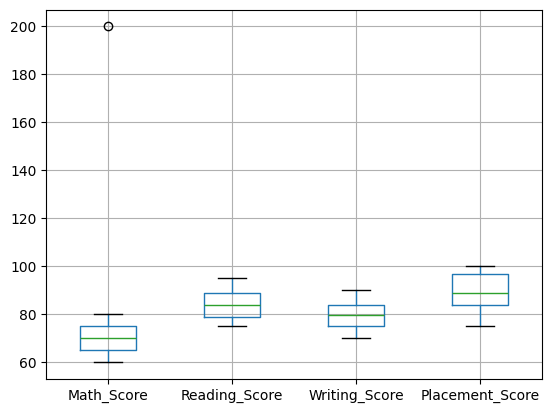

In [40]:
df.boxplot(column=['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score'])


In [41]:
import numpy as np
Q1 = np.percentile(df['Math_Score'], 25)
Q3 = np.percentile(df['Math_Score'], 75)

IQR = Q3 - Q1


In [42]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)


Lower Limit: 50.0
Upper Limit: 90.0


In [43]:
outliers = df[(df['Math_Score'] < lower) | (df['Math_Score'] > upper)]
print(outliers)


     Math_Score  Reading_Score  Writing_Score  Placement_Score  Club_Join  \
148       200.0           89.0           82.0             80.0     2022.0   

     Placement_Offers  
148                 1  


In [44]:
df = df.drop(df[(df['Math_Score'] < lower) |
                (df['Math_Score'] > upper)].index)


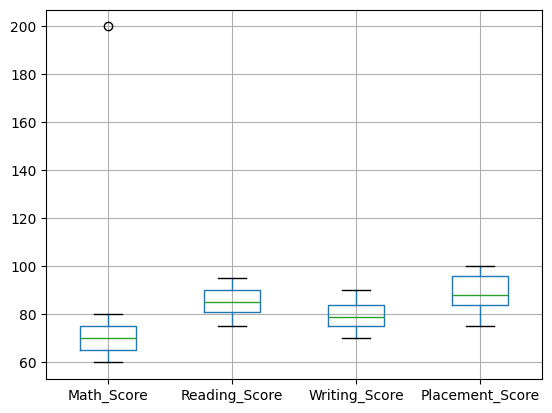

In [20]:
import matplotlib.pyplot as plt

df.boxplot(column=['Math_Score',
                   'Reading_Score',
                   'Writing_Score',
                   'Placement_Score'])

plt.show()
